In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable, axes_size as maxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.axes as maxes
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec

plot_path = '/home/u/u241308/figures/'

In [20]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [21]:
time_min = 1960
time_max = 2020

# Select lead years

In [22]:
lead_year = 1 #2

In [23]:
#1-13 for Dec-Nov first lead year, 13-25 for Dec-Nov second lead year
if lead_year == 1:
    lead_min = 0 # 2 to start in January, first lead year
    lead_max = 12 # 14 To end in December, first lead year
if lead_year == 2:
    lead_min = 12 # 14 to start in January, second lead year
    lead_max = 24 # 26 to end in December, second lead year

# Hybrid ML

In [24]:
# Load, slice, and collect datasets
sliced_datasets1 = []
sliced_datasets2 = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_ML_NA/anomaly/'
    file = 'sst_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_ML:
        sst_ML_ly1 = sst_ML.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets1.append(sst_ML_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))
    
#concatenate along time dimension
sst_ML_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
sst_ML_ly1['lon'] = np.where(sst_ML_ly1.lon > 180,sst_ML_ly1.lon-360,sst_ML_ly1.lon)
ind_sort = np.argsort(sst_ML_ly1.lon)
sst_ML_ly1 = sst_ML_ly1[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_ML_ly1 = sst_ML_ly1.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_ML_ly1 = sst_ML_ly1.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
sst_ML_ly1 = sst_ML_ly1.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [25]:
# Load, slice, and collect datasets
sliced_datasets1 = []
sliced_datasets2 = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_ML_NA/anomaly/'
    file = 'tas_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_ML:
        tas_ML_ly1 = tas_ML.tas.isel(time=slice(lead_min,lead_max))
    sliced_datasets1.append(tas_ML_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))
    
#concatenate along time dimension
tas_ML_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
tas_ML_ly1['lon'] = np.where(tas_ML_ly1.lon > 180,tas_ML_ly1.lon-360,tas_ML_ly1.lon)
ind_sort = np.argsort(tas_ML_ly1.lon)
tas_ML_ly1 = tas_ML_ly1[:,:,:,ind_sort.values]

#give different coordinates for each ensemble member in sfc:
tas_ML_ly1 = tas_ML_ly1.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
tas_ML_ly1 = tas_ML_ly1.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


# Standard

In [26]:
# Load, slice, and collect datasets
sliced_datasets1 = []
sliced_datasets2 = []
time_info1 = []
time_info2 = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_benchmark/anomaly/'
    file = 'sst_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_MPI:
        sst_MPI_ly1 = sst_MPI.tos.isel(time=slice(lead_min,lead_max))
        time_info1.append((sst_MPI_ly1.time.min(),sst_MPI_ly1.time.max()))      
    sliced_datasets1.append(sst_MPI_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))
    
#concatenate along time dimension
sst_MPI_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
sst_MPI_ly1['lon'] = np.where(sst_MPI_ly1.lon > 180,sst_MPI_ly1.lon-360,sst_MPI_ly1.lon)
ind_sort = np.argsort(sst_MPI_ly1.lon)
sst_MPI_ly1 = sst_MPI_ly1[:,:,:,ind_sort.values]

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_MPI_ly1 = sst_MPI_ly1.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_MPI_ly1 = sst_MPI_ly1.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
sst_MPI_ly1 = sst_MPI_ly1.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [27]:
# Load, slice, and collect datasets
sliced_datasets1 = []
sliced_datasets2 = []
time_info1 = []
time_info2 = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/tas_benchmark/anomaly/'
    file = 'tas_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as tas_MPI:
        tas_MPI_ly1 = tas_MPI.tas.isel(time=slice(lead_min,lead_max))
        time_info1.append((tas_MPI_ly1.time.min(),tas_MPI_ly1.time.max()))
    sliced_datasets1.append(tas_MPI_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))
    
#concatenate along time dimension
tas_MPI_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
tas_MPI_ly1['lon'] = np.where(tas_MPI_ly1.lon > 180,tas_MPI_ly1.lon-360,tas_MPI_ly1.lon)
ind_sort = np.argsort(tas_MPI_ly1.lon)
tas_MPI_ly1 = tas_MPI_ly1[:,:,:,ind_sort.values]

#give different coordinates for each ensemble member in sfc:
tas_MPI_ly1 = tas_MPI_ly1.assign_coords(sfc=np.arange(1, 17))

#ensemble mean
tas_MPI_ly1 = tas_MPI_ly1.mean(dim='sfc')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


# ERA5

In [28]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_sst_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
sst_era = xr.open_dataset(path+file).sst

#new longitudes
sst_era['lon'] = np.where(sst_era.lon > 180,sst_era.lon-360,sst_era.lon)
ind_sort = np.argsort(sst_era.lon)
sst_era = sst_era[:,:,ind_sort.values]

#homogenize to MPI and ML
sliced_datasets1 = []
for y_id,year in enumerate(np.arange(time_min,time_max)):
    sst_era_ly1 = sst_era[(sst_era.time.dt.floor('D')>=time_info1[y_id][0].dt.floor('D'))&(sst_era.time.dt.floor('D')<=time_info1[y_id][1].dt.floor('D'))]
    sliced_datasets1.append(sst_era_ly1.mean(dim='time').expand_dims(predicted_year=[year]))
    
#concatenate along time dimension
sst_era_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
sst_era_ly1['lon'] = np.where(sst_era_ly1.lon > 180,sst_era_ly1.lon-360,sst_era_ly1.lon)
ind_sort = np.argsort(sst_era_ly1.lon)
sst_era_ly1 = sst_era_ly1[:,:,ind_sort.values]

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [29]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_tas_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
tas_era = xr.open_dataset(path+file).t2m[:,0] #remove exp variable

#new longitudes
tas_era['lon'] = np.where(tas_era.lon > 180,tas_era.lon-360,tas_era.lon)
ind_sort = np.argsort(tas_era.lon)
tas_era = tas_era[:,:,ind_sort.values]

#homogenize to MPI and ML
sliced_datasets1 = []
sliced_datasets2 = []
for y_id,year in enumerate(np.arange(time_min,time_max)):
    tas_era_ly1 = tas_era[(tas_era.time.dt.floor('D')>=time_info1[y_id][0].dt.floor('D'))&(tas_era.time.dt.floor('D')<=time_info1[y_id][1].dt.floor('D'))]
    sliced_datasets1.append(tas_era_ly1.mean(dim='time').expand_dims(predicted_year=[year]))
    
#concatenate along time dimension
tas_era_ly1 = xr.concat(sliced_datasets1,dim='predicted_year')

#new longitudes
tas_era_ly1['lon'] = np.where(tas_era_ly1.lon > 180,tas_era_ly1.lon-360,tas_era_ly1.lon)
ind_sort = np.argsort(tas_era_ly1.lon)
tas_era_ly1 = tas_era_ly1[:,:,ind_sort.values]

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


# Correlation functions

In [30]:
def pearsonr_func(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)

    # mask NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    r, p = pearsonr(x[mask], y[mask])
    return r,p

In [31]:
def compute_correlation(x_corr,y_corr):
    r, p = xr.apply_ufunc(
        pearsonr_func,
        x_corr, y_corr,
        input_core_dims=[["predicted_year"], ["predicted_year"]],
        output_core_dims=[[], []],      # r and p are scalars per gridcell
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )
    return r,p

# North Atlantic region

In [32]:
lon_min = -100
lon_max = 40
lat_min = 0
lat_max = 80

#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

#select CE area
lon_min_ce = 5
lon_max_ce = 30#10
lat_min_ce = 48
lat_max_ce = 65#58

#select North America area
lon_min_nam = -77
lon_max_nam = -57
lat_min_nam = 47
lat_max_nam = 61

#select Greenland area
lon_min_gl = -55
lon_max_gl = -35
lat_min_gl = 60
lat_max_gl = 75

# Running window skill for each domain

In [33]:
period_min = 1960
period_max = 1990
window = 30

r_spg_ML_ly1_list = [] 
p_spg_ML_ly1_list = []
r_ce_ML_ly1_list = [] 
p_ce_ML_ly1_list = []
r_nam_ML_ly1_list = [] 
p_nam_ML_ly1_list = []
r_gl_ML_ly1_list = [] 
p_gl_ML_ly1_list = []
r_spg_MPI_ly1_list = [] 
p_spg_MPI_ly1_list = []
r_ce_MPI_ly1_list = [] 
p_ce_MPI_ly1_list = []
r_nam_MPI_ly1_list = [] 
p_nam_MPI_ly1_list = []
r_gl_MPI_ly1_list = [] 
p_gl_MPI_ly1_list = []

for y in range(period_min,period_max+1):
    w_start = y
    w_end = y+window

    #ERA
    sel_lon = (tas_era_ly1.lon>= lon_min_ce) & (tas_era_ly1.lon <= lon_max_ce)
    sel_lat = (tas_era_ly1.lat>= lat_min_ce) & (tas_era_ly1.lat <= lat_max_ce)
    tas_era_ly1_ce = tas_era_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_era_ly1.lon>= lon_min_nam) & (tas_era_ly1.lon <= lon_max_nam)
    sel_lat = (tas_era_ly1.lat>= lat_min_nam) & (tas_era_ly1.lat <= lat_max_nam)
    tas_era_ly1_nam = tas_era_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_era_ly1.lon>= lon_min_gl) & (tas_era_ly1.lon <= lon_max_gl)
    sel_lat = (tas_era_ly1.lat>= lat_min_gl) & (tas_era_ly1.lat <= lat_max_gl)
    tas_era_ly1_gl = tas_era_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (sst_era_ly1.lon>= lon_min_spg) & (sst_era_ly1.lon <= lon_max_spg)
    sel_lat = (sst_era_ly1.lat>= lat_min_spg) & (sst_era_ly1.lat <= lat_max_spg)
    sst_era_ly1_spg = sst_era_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    #MPI
    sel_lon = (tas_MPI_ly1.lon>= lon_min_ce) & (tas_MPI_ly1.lon <= lon_max_ce)
    sel_lat = (tas_MPI_ly1.lat>= lat_min_ce) & (tas_MPI_ly1.lat <= lat_max_ce)
    tas_MPI_ly1_ce = tas_MPI_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_MPI_ly1.lon>= lon_min_nam) & (tas_MPI_ly1.lon <= lon_max_nam)
    sel_lat = (tas_MPI_ly1.lat>= lat_min_nam) & (tas_MPI_ly1.lat <= lat_max_nam)
    tas_MPI_ly1_nam = tas_MPI_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_MPI_ly1.lon>= lon_min_gl) & (tas_MPI_ly1.lon <= lon_max_gl)
    sel_lat = (tas_MPI_ly1.lat>= lat_min_gl) & (tas_MPI_ly1.lat <= lat_max_gl)
    tas_MPI_ly1_gl = tas_MPI_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (sst_MPI_ly1.lon>= lon_min_spg) & (sst_MPI_ly1.lon <= lon_max_spg)
    sel_lat = (sst_MPI_ly1.lat>= lat_min_spg) & (sst_MPI_ly1.lat <= lat_max_spg)
    sst_MPI_ly1_spg = sst_MPI_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    #ML
    sel_lon = (tas_ML_ly1.lon>= lon_min_ce) & (tas_ML_ly1.lon <= lon_max_ce)
    sel_lat = (tas_ML_ly1.lat>= lat_min_ce) & (tas_ML_ly1.lat <= lat_max_ce)
    tas_ML_ly1_ce = tas_ML_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_ML_ly1.lon>= lon_min_nam) & (tas_ML_ly1.lon <= lon_max_nam)
    sel_lat = (tas_ML_ly1.lat>= lat_min_nam) & (tas_ML_ly1.lat <= lat_max_nam)
    tas_ML_ly1_nam = tas_ML_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (tas_ML_ly1.lon>= lon_min_gl) & (tas_ML_ly1.lon <= lon_max_gl)
    sel_lat = (tas_ML_ly1.lat>= lat_min_gl) & (tas_ML_ly1.lat <= lat_max_gl)
    tas_ML_ly1_gl = tas_ML_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))
    
    sel_lon = (sst_ML_ly1.lon>= lon_min_spg) & (sst_ML_ly1.lon <= lon_max_spg)
    sel_lat = (sst_ML_ly1.lat>= lat_min_spg) & (sst_ML_ly1.lat <= lat_max_spg)
    sst_ML_ly1_spg = sst_ML_ly1[:,sel_lat,sel_lon].mean(dim=('lon','lat'))

    #SPG
    #MPI
    x_corr = sst_era_ly1_spg.sel(predicted_year=slice(w_start,w_end))
    y_corr = sst_MPI_ly1_spg.sel(predicted_year=slice(w_start,w_end))
    r_spg_MPI_ly1_per, p_spg_MPI_ly1_per = compute_correlation(x_corr,y_corr)
    
    #ML
    x_corr = sst_era_ly1_spg.sel(predicted_year=slice(w_start,w_end))
    y_corr = sst_ML_ly1_spg.sel(predicted_year=slice(w_start,w_end))
    r_spg_ML_ly1_per, p_spg_ML_ly1_per = compute_correlation(x_corr,y_corr)
    
    #CE Tas
    #MPI
    x_corr = tas_era_ly1_ce.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_MPI_ly1_ce.sel(predicted_year=slice(w_start,w_end))
    r_ce_MPI_ly1_per, p_ce_MPI_ly1_per = compute_correlation(x_corr,y_corr)
    
    #ML
    x_corr = tas_era_ly1_ce.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_ML_ly1_ce.sel(predicted_year=slice(w_start,w_end))
    r_ce_ML_ly1_per, p_ce_ML_ly1_per = compute_correlation(x_corr,y_corr)
    
    #NAM Tas
    #MPI
    x_corr = tas_era_ly1_nam.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_MPI_ly1_nam.sel(predicted_year=slice(w_start,w_end))
    r_nam_MPI_ly1_per, p_nam_MPI_ly1_per = compute_correlation(x_corr,y_corr)
    
    #ML
    x_corr = tas_era_ly1_nam.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_ML_ly1_nam.sel(predicted_year=slice(w_start,w_end))
    r_nam_ML_ly1_per, p_nam_ML_ly1_per = compute_correlation(x_corr,y_corr)
    
    #GL Tas
    #MPI
    x_corr = tas_era_ly1_gl.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_MPI_ly1_gl.sel(predicted_year=slice(w_start,w_end))
    r_gl_MPI_ly1_per, p_gl_MPI_ly1_per = compute_correlation(x_corr,y_corr)
    
    #ML
    x_corr = tas_era_ly1_gl.sel(predicted_year=slice(w_start,w_end))
    y_corr = tas_ML_ly1_gl.sel(predicted_year=slice(w_start,w_end))
    r_gl_ML_ly1_per, p_gl_ML_ly1_per = compute_correlation(x_corr,y_corr)

    #APPEND
    r_spg_ML_ly1_list.append(r_spg_ML_ly1_per)
    p_spg_ML_ly1_list.append(p_spg_ML_ly1_per)
    r_ce_ML_ly1_list.append(r_ce_ML_ly1_per)
    p_ce_ML_ly1_list.append(p_ce_ML_ly1_per)
    r_nam_ML_ly1_list.append(r_nam_ML_ly1_per)
    p_nam_ML_ly1_list.append(p_nam_ML_ly1_per)
    r_gl_ML_ly1_list.append(r_gl_ML_ly1_per)
    p_gl_ML_ly1_list.append(p_gl_ML_ly1_per)

    r_spg_MPI_ly1_list.append(r_spg_MPI_ly1_per)
    p_spg_MPI_ly1_list.append(p_spg_MPI_ly1_per)
    r_ce_MPI_ly1_list.append(r_ce_MPI_ly1_per)
    p_ce_MPI_ly1_list.append(p_ce_MPI_ly1_per)
    r_nam_MPI_ly1_list.append(r_nam_MPI_ly1_per)
    p_nam_MPI_ly1_list.append(p_nam_MPI_ly1_per)
    r_gl_MPI_ly1_list.append(r_gl_MPI_ly1_per)
    p_gl_MPI_ly1_list.append(p_gl_MPI_ly1_per)

    print('Window starting on %i done' %w_start)

Window starting on 1960 done
Window starting on 1961 done
Window starting on 1962 done
Window starting on 1963 done
Window starting on 1964 done
Window starting on 1965 done
Window starting on 1966 done
Window starting on 1967 done
Window starting on 1968 done
Window starting on 1969 done
Window starting on 1970 done
Window starting on 1971 done
Window starting on 1972 done
Window starting on 1973 done
Window starting on 1974 done
Window starting on 1975 done
Window starting on 1976 done
Window starting on 1977 done
Window starting on 1978 done
Window starting on 1979 done
Window starting on 1980 done
Window starting on 1981 done
Window starting on 1982 done
Window starting on 1983 done
Window starting on 1984 done
Window starting on 1985 done
Window starting on 1986 done
Window starting on 1987 done
Window starting on 1988 done
Window starting on 1989 done
Window starting on 1990 done


# Relate skill improvement to obs number

In [35]:
obs_file = '/work/uo1075/u301617/Master_Arbeit/data/input-nc-files/en4_profiles.nc'
n_obs = xr.open_dataset(obs_file)

# sum observations from temperature and salinity
n_obs_total = n_obs.tho + n_obs.sao

# 30 year running mean, with the value left-aligned
n_obs_total_rwindow = n_obs_total.rolling(time=30).mean().shift(time=-29)

#remove NANs due to running window
n_obs_total_rwindow = n_obs_total_rwindow.dropna("time")

# correct time
time_vals = n_obs_total_rwindow.time.values
years = (time_vals // 100).astype(int)
months = (time_vals % 100).astype(int)
new_time = pd.to_datetime(
    dict(year=years, month=months, day=15)
)
n_obs_total_rwindow = n_obs_total_rwindow.assign_coords(
    time=("time", new_time)
)

#select years
n_obs_total_rwindow = n_obs_total_rwindow[(n_obs_total_rwindow.time.dt.year>=period_min)&(n_obs_total_rwindow.time.dt.year<=period_max)]

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/conventions.py:427: SerializationWarning: variable 'sao' has multiple fill values {-9e+33, '-9.e+33f'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/conventions.py:427: SerializationWarning: variable 'tho' has multiple fill values {-9e+33, '-9.e+33f'}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/coding/variables.py:213: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  condition |= data == fv


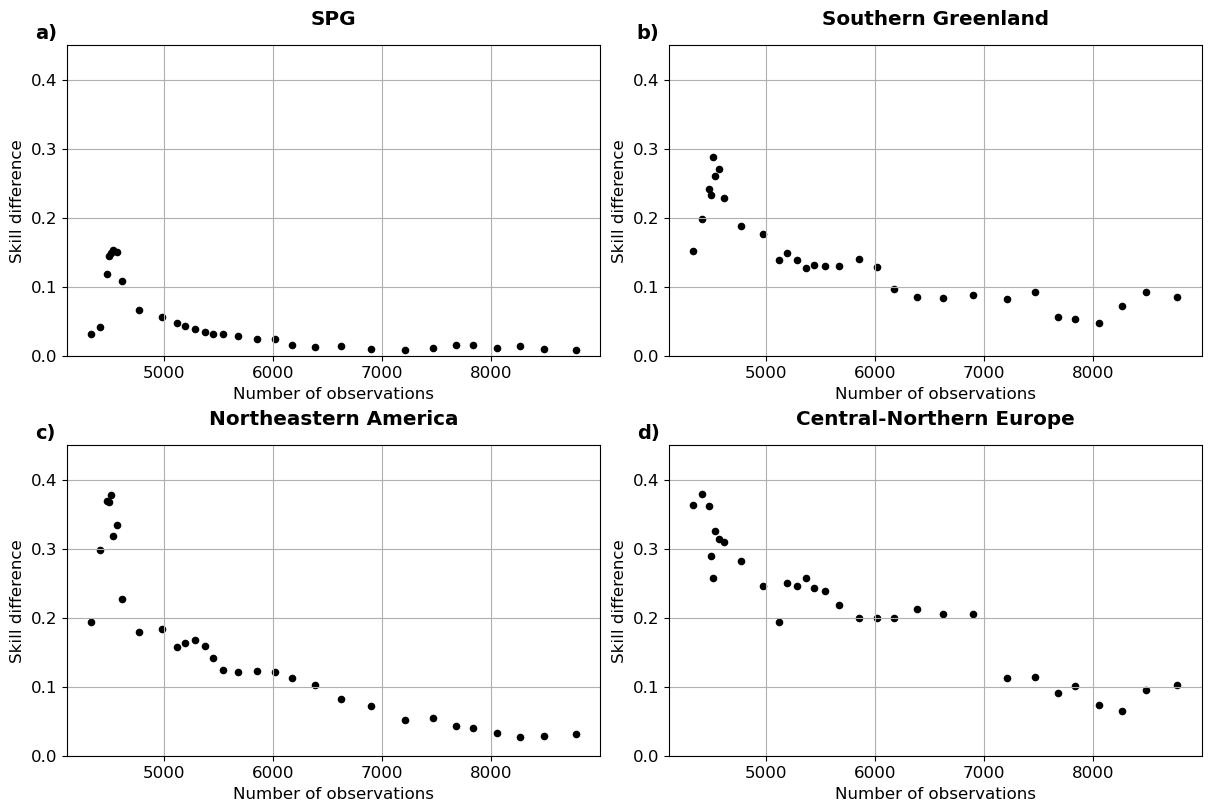

In [36]:
ylim_min_diff = 0
ylim_max_diff = 0.45
#fig = plt.figure(figsize=(15,8))#(22,15))
fig = plt.figure(figsize=(12,8), constrained_layout=True)
plt.rcParams.update({'font.size': 12})


# ==================== SPG =====================
ax1= fig.add_subplot(2,2,1)
ax1.scatter(n_obs_total_rwindow,
            (np.array(r_spg_ML_ly1_list)-np.array(r_spg_MPI_ly1_list)),
            marker='.', color='k', s=80, label='_nolegend_')

plt.ylim([ylim_min_diff,ylim_max_diff])
plt.grid()
#ax1.text(0.5, 1.05, 'SPG', transform=ax1.transAxes, ha='center', va='bottom', fontweight='bold',color='k')
ax1.set_title('SPG', pad=15, fontweight='bold')
ax1.set_ylabel('Skill difference')
ax1.set_xlabel('Number of observations')
ax1.set_yticks([0, 0.1, 0.2, 0.3, 0.4])

# ==================== Central-northern Europe =====================

ax2= fig.add_subplot(2,2,4)
ax2.scatter(n_obs_total_rwindow,
            (np.array(r_ce_ML_ly1_list)-np.array(r_ce_MPI_ly1_list)),
            marker='.', color='k', s=80, label='_nolegend_')

plt.ylim([ylim_min_diff,ylim_max_diff])
plt.grid()
#ax2.text(0.5, 1.05, 'Central-Northern Europe', transform=ax2.transAxes, ha='center', va='bottom', fontweight='bold',color='k')
ax2.set_title('Central-Northern Europe', pad=15, fontweight='bold')
ax2.set_ylabel('Skill difference')
ax2.set_xlabel('Number of observations')
ax2.set_yticks([0, 0.1, 0.2, 0.3, 0.4])

# ==================== Northeastern America =====================
ax3= fig.add_subplot(2,2,3)
ax3.scatter(n_obs_total_rwindow,
            (np.array(r_nam_ML_ly1_list)-np.array(r_nam_MPI_ly1_list)),
            marker='.', color='k', s=80, label='_nolegend_')

plt.ylim([ylim_min_diff,ylim_max_diff])
plt.grid()
#ax3.text(0.5, 1.05, 'Northeastern America', transform=ax3.transAxes, ha='center', va='bottom', fontweight='bold',color='k')
ax3.set_title('Northeastern America', pad=15, fontweight='bold')
ax3.set_ylabel('Skill difference')
ax3.set_xlabel('Number of observations')
ax3.set_yticks([0, 0.1, 0.2, 0.3, 0.4])

# ==================== Southern Greenland =====================
ax4= fig.add_subplot(2,2,2)
ax4.scatter(n_obs_total_rwindow,
            (np.array(r_gl_ML_ly1_list)-np.array(r_gl_MPI_ly1_list)),
            marker='.', color='k', s=80, label='_nolegend_')

plt.ylim([ylim_min_diff,ylim_max_diff])
plt.grid()
#ax4.text(0.5, 1.05, 'Southern Greenland', transform=ax4.transAxes, ha='center', va='bottom', fontweight='bold',color='k')
ax4.set_title('Southern Greenland', pad=15, fontweight='bold')
ax4.set_ylabel('Skill difference')
ax4.set_xlabel('Number of observations')
ax4.set_yticks([0, 0.1, 0.2, 0.3, 0.4])

#================== a,b,c,d =========================
x_pos = -0.06
y_pos = 1.07
ax1.text(
    x_pos, y_pos, 'a)',   # position (x,y)
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

ax2.text(
    x_pos, y_pos, 'd)',   # position (x,y)
    transform=ax2.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax3.text(
    x_pos, y_pos, 'c)',   # position (x,y)
    transform=ax3.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)
ax4.text(
    x_pos, y_pos, 'b)',   # position (x,y)
    transform=ax4.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold'
)

if lead_year == 1:
    plt.savefig(plot_path+'skill_difference_1leadyear_vs_number_observations_anomaly_ref_%i-%i'%(ref_min,ref_max),bbox_inches="tight",dpi=100) 
if lead_year == 2:
    plt.savefig(plot_path+'skill_difference_2leadyear_vs_number_observations_anomaly_ref_%i-%i'%(ref_min,ref_max),bbox_inches="tight",dpi=100) 